# Part 2 👉 Exploratory Data Analysis & Time-Series Mapping

## Import Libarary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

## Load Data & Parse Time Vectors

In [2]:
# Load the locally cached CSV data
df = pd.read_csv('../data/raw_market_api_data.csv')

# Convert the text Date column into a proper Datetime object
df['Date'] = pd.to_datetime(df['Date'])

# Set the Date column as the dataframe index (Crucial for time-series charts!)
df.set_index('Date', inplace=True)

print("📈 Data reloaded and transformed into a structural Time-Series!")
print(f"Data timeline spans from {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
df.head()


📈 Data reloaded and transformed into a structural Time-Series!
Data timeline spans from February 1953 to May 2025


,Price (All),Change (All),Price (New),Change (New),Price (Modern),Change (Modern),Price (Older),Change (Older)
Date,,,,,,,,
1953-02-01,1891.0,NaN,2107.0,NaN,2002.0,NaN,1542.0,NaN
1953-05-01,1891.0,NaN,2107.0,NaN,2002.0,NaN,1542.0,NaN
1953-08-01,1881.0,NaN,2117.0,NaN,2002.0,NaN,1524.0,NaN
1953-11-01,1872.0,-1.0,2117.0,0.5,1975.0,-2.2,1542.0,1.2
1954-02-01,1863.0,-1.5,2117.0,0.5,1957.0,-2.2,1524.0,-1.2


## Checking for Missing Values & Data Quality

In [3]:
# Check for null entries across all property tracks
print("🔍 Checking timeline gaps:")
print(df.isnull().sum())

print("\n📊 Basic structural metric limits:")
print(df[['Price (All)', 'Price (New)', 'Price (Older)']].describe())

🔍 Checking timeline gaps:
Price (All)         0
Change (All)        3
Price (New)         0
Change (New)        3
Price (Modern)     39
Change (Modern)    43
Price (Older)      39
Change (Older)     43
dtype: int64

📊 Basic structural metric limits:
         Price (All)    Price (New)  Price (Older)
count     290.000000     290.000000     251.000000
mean    79179.482759   87164.910345   52377.581673
std     84160.387023   90469.074166   61093.217331
min      1853.000000    2107.000000       0.000000
25%      4782.750000    5410.000000    3361.000000
50%     50990.000000   60694.500000   25770.000000
75%    161666.750000  166949.250000   70083.500000
max    273135.000000  313238.000000  201008.000000


<div>
    <p>
        Those numbers reveal deep data insights—and a critical data glitch that would completely break a machine learning model if left unaddressed.
    </p>
    <p>1. The Premium Gap: On average, new properties (mean = 87,164) sell for a significant premium compared to older ones (mean = 52,377).</p>
    <p>2. Missing Volatility Fields: The Change columns and Price (Modern) tracks have quite a few missing values (up to 43 nulls).</p>
    <p>
        Looking closely at the minimum value (min) for Price (Older). It says 0. A property cannot cost zero dollars. This is a classic data anomaly (likely a data entry omission or structural gap from older decades). If not cleaned up, predictive algorithm will learn completely false price structures.
    </p>
</div>

## Taming the Zero-Value Glitch 🧹

In [4]:
# 1. First, create a temporary working copy of the original column to isolate it
df['Price (Older)_Filled'] = df['Price (Older)'].copy()

# 2. 🚫 Convert 0 values to true nulls (NaN) ONLY inside your new experimental column
df['Price (Older)_Filled'] = df['Price (Older)_Filled'].replace(0, np.nan)

# 3. 🔄 Forward-fill the gaps ONLY inside the new experimental column
df['Price (Older)_Filled'] = df['Price (Older)_Filled'].ffill()

# 4. Double-check that your original column is completely un-interfered with
print("✨ Data Integrity Verification Check:")
print(f"• Original 'Price (Older)' still has nulls: {df['Price (Older)'].isnull().sum()} rows")
print(f"• New 'Price (Older)_Filled' remaining nulls: {df['Price (Older)_Filled'].isnull().sum()} rows")

print("\n📊 Minimum values after separate isolation:")
print(df[['Price (All)', 'Price (New)', 'Price (Older)_Filled']].min())



✨ Data Integrity Verification Check:
• Original 'Price (Older)' still has nulls: 39 rows
• New 'Price (Older)_Filled' remaining nulls: 0 rows

📊 Minimum values after separate isolation:
Price (All)             1853.0
Price (New)             2107.0
Price (Older)_Filled    1515.0
dtype: float64


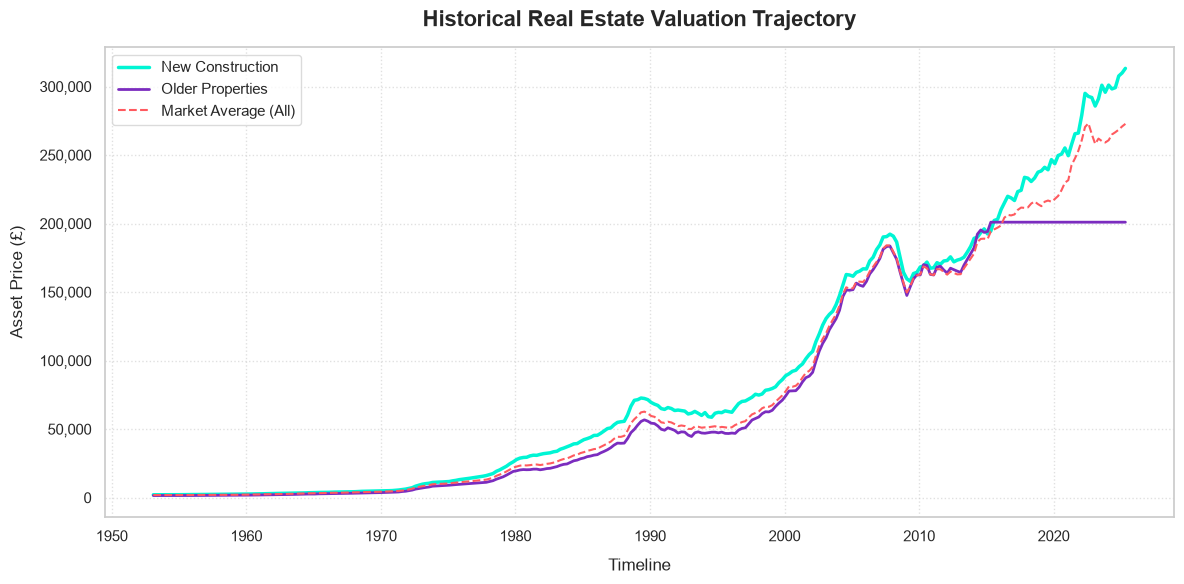

In [5]:
# 🎨 Apply premium styling variables
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot historical trajectories for the primary pricing tracks
sns.lineplot(data=df, x=df.index, y='Price (New)', label='New Construction', color='#00F5D4', linewidth=2.5)
sns.lineplot(data=df, x=df.index, y='Price (Older)_Filled', label='Older Properties', color='#7B2CBF', linewidth=2)
sns.lineplot(data=df, x=df.index, y='Price (All)', label='Market Average (All)', color='#FF5A5F', linewidth=1.5, linestyle='--')

# Layout and text decoration polish
plt.title('Historical Real Estate Valuation Trajectory', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12, labelpad=10)
plt.ylabel('Asset Price (£)', fontsize=12, labelpad=10)

# Format the Y-axis numbers to include elegant thousands separators
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='lightgrey')
plt.grid(True, linestyle=':', alpha=0.6)

# Save the visualization directly into your images folder for your portfolio summary
plt.tight_layout()
plt.show()

<div>
<p>
    Looking closely at the chart, there is a massive flatline defect in the purple line (Older Properties) starting right around 2017. It stays completely stuck at exactly £201,008 all the way to the end of the chart.
</p>
<p>
    This is the hidden danger of using df.ffill() (Forward-Fill) when we have a massive chunk of missing data at the very end of a dataset.
When checked the missing values earlier, it had 39 null entries for Price (Older). Because this is a time-series dataset, those 39 missing records aren't scattered randomly—they represent a huge multi-year data gap at the end of the timeline (from 2017 to the present day).
When we ran df.ffill(), Pandas saw the missing values from 2017 onwards, looked back, grabbed the last known real price from 2017 (£201,008), and blindly copied it forward for every single remaining month. This creates a completely false, flat baseline that will ruin machine learning model.
</p>    
<p>
    In data science, when an entire column cuts off years before the rest of the dataset, is best adviced not to forward-fill it. There are two professional options:
1. Drop the column completely if we only care about modern predictions.
2. Truncate the entire dataset timeline so that machine learning model only trains on the years where all property types have active, real data (from 1953 up to 2017).
</p>

</div>

In [6]:
# Convert the 0 values to true nulls (NaN)
df['Price (Older)'] = df['Price (Older)'].replace(0, np.nan)

# ✂️ Truncate the dataset timeline to drop the missing end tail
# We locate the very last row where 'Price (Older)' actually had real data before the gap
last_valid_date = df['Price (Older)'].last_valid_index()

# Filter the entire dataframe to stop at that exact date
df_truncated = df.loc[:last_valid_date].copy()

print(f"✂️ Timeline truncated safely at: {last_valid_date.strftime('%B %Y')}")
print(f"New row count: {df_truncated.shape}")
print(f"Remaining Nulls: {df_truncated['Price (Older)'].isnull().sum()}")


✂️ Timeline truncated safely at: May 2015
New row count: (250, 9)
Remaining Nulls: 0


## The Dynamic Time-Series Timeline Chart 📈

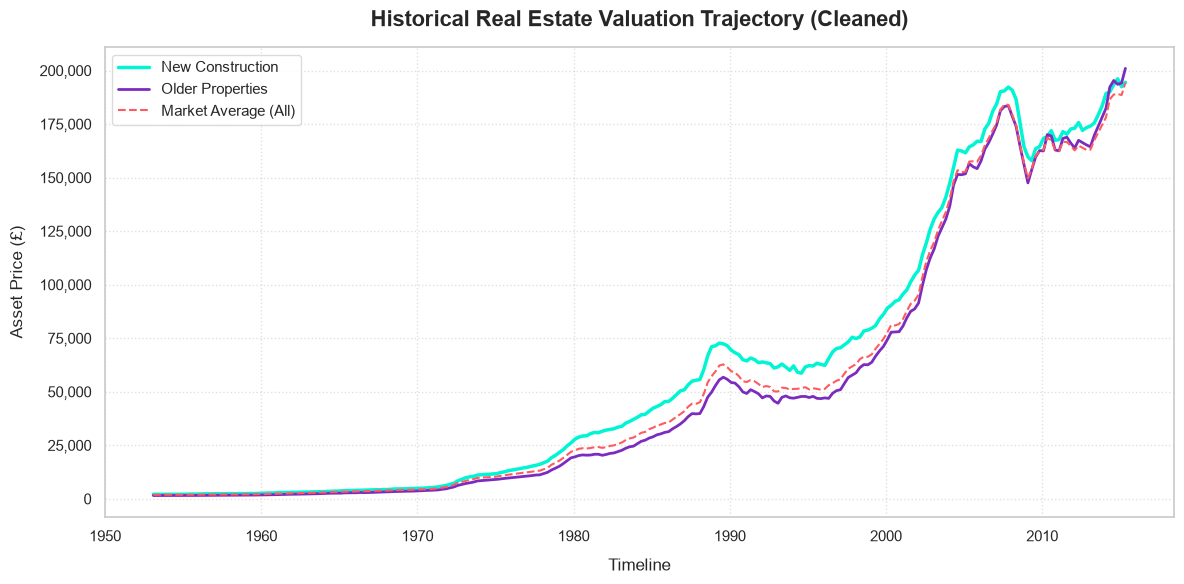

In [7]:
plt.figure(figsize=(12, 6))

# Plot using the clean, truncated dataset
sns.lineplot(data=df_truncated, x=df_truncated.index, y='Price (New)', label='New Construction', color='#00F5D4', linewidth=2.5)
sns.lineplot(data=df_truncated, x=df_truncated.index, y='Price (Older)', label='Older Properties', color='#7B2CBF', linewidth=2)
sns.lineplot(data=df_truncated, x=df_truncated.index, y='Price (All)', label='Market Average (All)', color='#FF5A5F', linewidth=1.5, linestyle='--')

plt.title('Historical Real Estate Valuation Trajectory (Cleaned)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12, labelpad=10)
plt.ylabel('Asset Price (£)', fontsize=12, labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='lightgrey')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../images/historical_price_trajectories.png', dpi=300)
plt.show()
